In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [83]:
x=6*np.random.rand(100,1)-3
y=0.5 * x**2+1.5*x+2+np.random.randn(100,1)

## here we used a quadratic equation to get non_linear data ax^2+bx+c=0 where (0.5X^2+1.5X+C+Outliers)

In [84]:
x.shape

(100, 1)

In [85]:
y.shape

(100, 1)

Text(0, 0.5, 'y dataset')

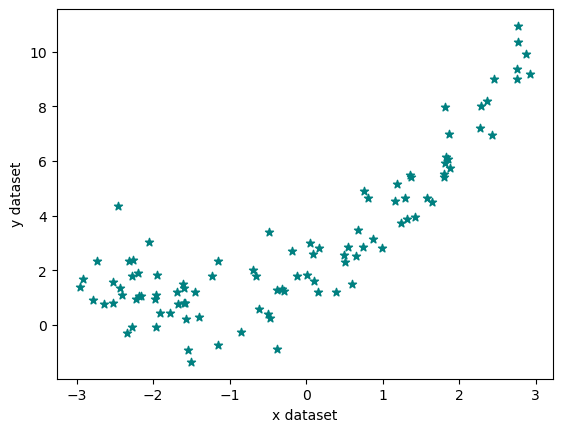

In [86]:
plt.scatter(x,y,marker='*',color='teal')
plt.xlabel('x dataset')
plt.ylabel('y dataset')

In [87]:
## apply linear regression
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42) 

In [88]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [89]:
y_pred=regression.predict(x_test)

In [90]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.5627176681058319


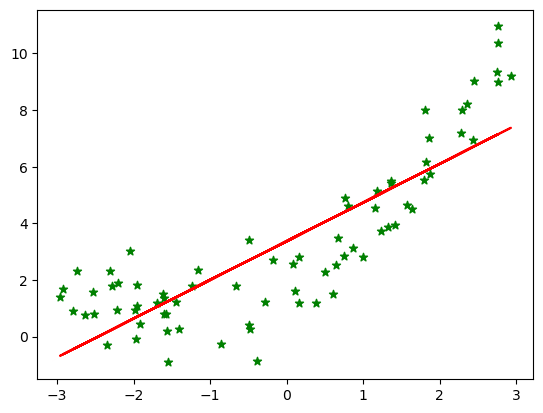

In [91]:
plt.scatter(x_train,y_train,marker='*',color="green")
plt.plot(x_train,regression.predict(x_train),color='red')

In [92]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2,include_bias=True)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [93]:
model=LinearRegression()
model.fit(x_train_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [94]:
y_predic=model.predict(x_test_poly)

In [95]:
print(model.coef_)
print(model.intercept_)

[[0.         1.4278555  0.49379885]]
[1.8290795]


In [96]:
new_score=r2_score(y_test,y_predic)
print(new_score)

0.8500331612885809


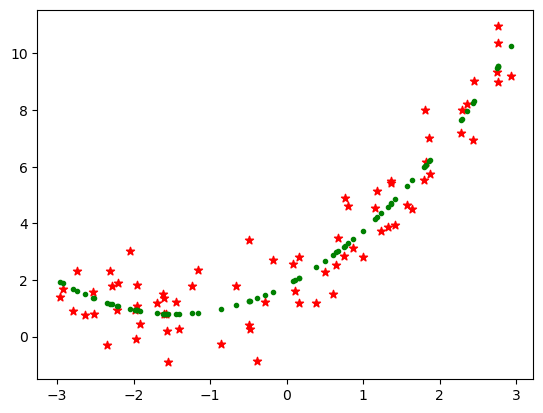

In [97]:
plt.scatter(x_train,y_train,color='red',marker='*')
plt.plot(x_train,model.predict(x_train_poly),'g.')

In [98]:
##prediction for new data
x_new=np.linspace(-3,3,200).reshape(200,1)
x_new_poly=poly.transform(x_new)

In [99]:
y_new=model.predict(x_new_poly)

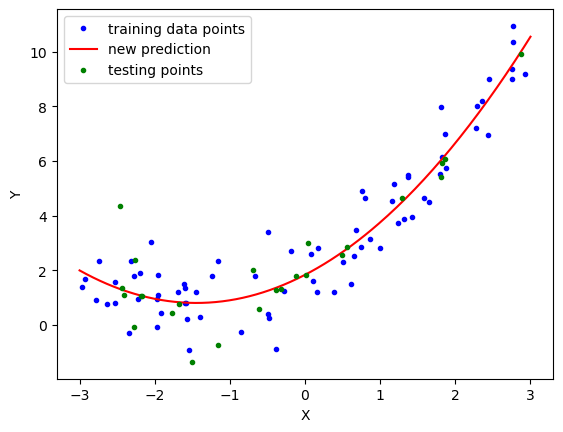

In [100]:
plt.plot(x_train,y_train,'b.',label='training data points')
plt.plot(x_new,y_new,'r-',label='new prediction')
plt.plot(x_test,y_test,'g.',label='testing points')
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

## Pipeline Concept

In [101]:
from sklearn.pipeline import Pipeline


In [116]:
def poly_regression(degree):
    x_new=np.linspace(-3,3,200).reshape(200,1)

    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ('Poly Features',poly_features),
        ('linear regression',lin_reg)
    ])
    poly_regression.fit(x_train,y_train)
    y_new=poly_regression.predict(x_new)

    ##plotting prediction lines
    plt.plot(x_new,y_new,'r-',label='Degree'  +  str(degree), linewidth=3)
    plt.plot(x_train,y_train,'b.',linewidth=3)
    plt.plot(x_test,y_test,'g.',linewidth=3)
    plt.legend(loc='upper left')
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0,10])
    plt.show()

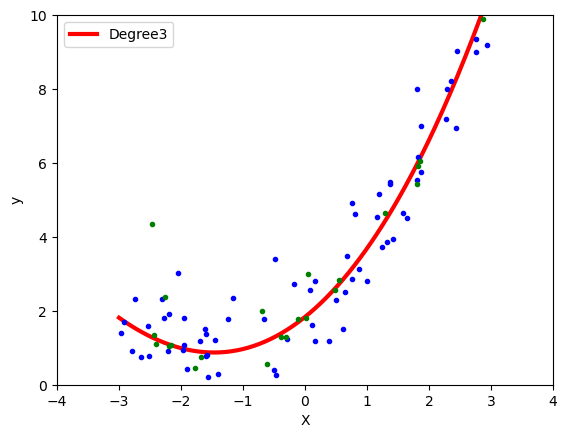

In [126]:
poly_regression(3)